## Load the CSV

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('data/Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [4]:
df.rename(columns={
    "Store" : "store",
    "Date" : "date",
    "Weekly_Sales": "weekly_sales",
    "Holiday_Flag": "holiday",
    "Temperature" : "temperature",
    "Fuel_Price": "gas_price",
    "CPI": "consumer_price_index",
    "Unemployment": "unemployment_rate",
    "Weekly_Sales" : "sales"
}, inplace=True)

In [5]:
df.head()

,store,date,sales,holiday,temperature,gas_price,consumer_price_index,unemployment_rate
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [6]:
df.shape

(6435, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   store                 6435 non-null   int64  
 1   date                  6435 non-null   object 
 2   sales                 6435 non-null   float64
 3   holiday               6435 non-null   int64  
 4   temperature           6435 non-null   float64
 5   gas_price             6435 non-null   float64
 6   consumer_price_index  6435 non-null   float64
 7   unemployment_rate     6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [8]:
df.describe()

,store,sales,holiday,temperature,gas_price,consumer_price_index,unemployment_rate
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [9]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

# Create new columns
df["month"] = df["date"].dt.month_name()   # January, February, ...
df["year"] = df["date"].dt.year            # 2010, 2011, 2012

# Preview
df.head()

,store,date,sales,holiday,temperature,gas_price,consumer_price_index,unemployment_rate,month,year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,February,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,February,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,February,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,February,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,March,2010


In [10]:
def temp_category(x):
    if x < 40:
        return "Cold"
    elif x < 70:
        return "Moderate"
    else:
        return "Hot"

df["temperature_category"] = df["temperature"].apply(temp_category)

In [11]:
df["fuel_price_level"] = pd.cut(
    df["gas_price"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

In [12]:
df["consumer_price_level"] = pd.qcut(
    df["consumer_price_index"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [13]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["date"].dt.month.map(get_season)

In [14]:
df["unemployment_level"] = pd.qcut(
    df["unemployment_rate"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [15]:
df["holiday"] = df["holiday"].map({
    0: "Non-Holiday",
    1: "Holiday"
})

In [16]:
# Day features
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["date"].dt.dayofweek >= 5
df["day_type"] = df["is_weekend"].map({True: "Weekend", False: "Weekday"})

In [17]:
df.head()

,store,date,sales,holiday,temperature,gas_price,consumer_price_index,unemployment_rate,month,year,temperature_category,fuel_price_level,consumer_price_level,season,unemployment_level,day_of_week,is_weekend,day_type
0,1,2010-02-05,1643690.90,Non-Holiday,42.31,2.572,211.096358,8.106,February,2010,Moderate,Low,High,Winter,Medium,Friday,False,Weekday
1,1,2010-02-12,1641957.44,Holiday,38.51,2.548,211.242170,8.106,February,2010,Cold,Low,High,Winter,Medium,Friday,False,Weekday
2,1,2010-02-19,1611968.17,Non-Holiday,39.93,2.514,211.289143,8.106,February,2010,Cold,Low,High,Winter,Medium,Friday,False,Weekday
3,1,2010-02-26,1409727.59,Non-Holiday,46.63,2.561,211.319643,8.106,February,2010,Moderate,Low,High,Winter,Medium,Friday,False,Weekday
4,1,2010-03-05,1554806.68,Non-Holiday,46.50,2.625,211.350143,8.106,March,2010,Moderate,Low,High,Spring,Medium,Friday,False,Weekday


In [18]:
df.columns

Index(['store', 'date', 'sales', 'holiday', 'temperature', 'gas_price',
       'consumer_price_index', 'unemployment_rate', 'month', 'year',
       'temperature_category', 'fuel_price_level', 'consumer_price_level',
       'season', 'unemployment_level', 'day_of_week', 'is_weekend',
       'day_type'],
      dtype='object')

In [19]:
keep_cols = [
    'store', 'holiday',
    'fuel_price_level', 'consumer_price_level', 'unemployment_level',
    'season', 'temperature_category', 'day_type',
    'date', 'month', 'year',
    'sales'
]

df = df[keep_cols]

In [20]:
df.head()

,store,holiday,fuel_price_level,consumer_price_level,unemployment_level,season,temperature_category,day_type,date,month,year,sales
0,1,Non-Holiday,Low,High,Medium,Winter,Moderate,Weekday,2010-02-05,February,2010,1643690.90
1,1,Holiday,Low,High,Medium,Winter,Cold,Weekday,2010-02-12,February,2010,1641957.44
2,1,Non-Holiday,Low,High,Medium,Winter,Cold,Weekday,2010-02-19,February,2010,1611968.17
3,1,Non-Holiday,Low,High,Medium,Winter,Moderate,Weekday,2010-02-26,February,2010,1409727.59
4,1,Non-Holiday,Low,High,Medium,Spring,Moderate,Weekday,2010-03-05,March,2010,1554806.68


In [21]:
df.to_csv("data/walmart_processed.csv", index=False)

In [22]:
df = pd.read_csv('data/walmart_processed.csv')
df.head()

,store,holiday,fuel_price_level,consumer_price_level,unemployment_level,season,temperature_category,day_type,date,month,year,sales
0,1,Non-Holiday,Low,High,Medium,Winter,Moderate,Weekday,2010-02-05,February,2010,1643690.90
1,1,Holiday,Low,High,Medium,Winter,Cold,Weekday,2010-02-12,February,2010,1641957.44
2,1,Non-Holiday,Low,High,Medium,Winter,Cold,Weekday,2010-02-19,February,2010,1611968.17
3,1,Non-Holiday,Low,High,Medium,Winter,Moderate,Weekday,2010-02-26,February,2010,1409727.59
4,1,Non-Holiday,Low,High,Medium,Spring,Moderate,Weekday,2010-03-05,March,2010,1554806.68


In [23]:
import os
from langchain_openai import ChatOpenAI
from langchain_experimental.agents import create_pandas_dataframe_agent

/var/folders/wt/f5tjfmdj3p550q42d1n61syw0000gn/T/ipykernel_17831/3393620288.py:3: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.agents import create_pandas_dataframe_agent


In [24]:
import os
from langchain_openai import ChatOpenAI

# set credential
with open("keys/openai_api_key.txt") as f:
    os.environ["OPENAI_API_KEY"] = f.read().strip()

# load model (it automatically reads env var)
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# test
# print(llm.invoke("Hello").content)

In [25]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

# ==========================================
# 1. Define LangGraph State & Node
# ==========================================
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    code: str

# Build the agent once at module scope (llm and df assumed defined elsewhere)
agent_executor = create_pandas_dataframe_agent(
    llm, df,
    agent_type="tool-calling",
    allow_dangerous_code=True,
    verbose=False,
    return_intermediate_steps=True,
)

def pandas_agent_node(state: AgentState, config):
    # Pass the latest message content as a string, not the raw message list
    response = agent_executor.invoke({"input": state["messages"][-1].content})

    # Extract the code from each tool call
    code_blocks = []
    for action, observation in response["intermediate_steps"]:
        ti = action.tool_input
        code = ti["query"] if isinstance(ti, dict) else ti  # tool-calling -> dict
        code_blocks.append(code)

    full_code = "\n\n".join(code_blocks) if code_blocks else "# (no code executed)"

    return {
        "messages": [AIMessage(content=response["output"])],
        "code": full_code,
    }

# ==========================================
# 2. Build and Compile the Graph
# ==========================================
workflow = StateGraph(AgentState)
workflow.add_node("pandas_agent", pandas_agent_node)
workflow.add_edge(START, "pandas_agent")
workflow.add_edge("pandas_agent", END)
agent = workflow.compile()

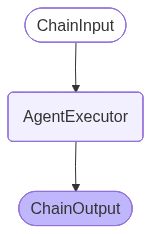

In [26]:
from IPython.display import Image, display

display(Image(agent_executor.get_graph().draw_mermaid_png()))

In [27]:
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

agent_executor = create_pandas_dataframe_agent(
    llm, df,
    agent_type="tool-calling",
    allow_dangerous_code=True,
    verbose=False,
)

def run_agent(question: str) -> str:
    return agent_executor.invoke({"input": question})["output"]

In [28]:
print(run_agent("Top 5 stores by sales?"))

The top 5 stores by sales are as follows:

1. Store 20: 301,397,800
2. Store 4: 299,544,000
3. Store 14: 288,999,900
4. Store 13: 286,517,700
5. Store 2: 275,382,400


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   store                 6435 non-null   int64  
 1   holiday               6435 non-null   object 
 2   fuel_price_level      6435 non-null   object 
 3   consumer_price_level  6435 non-null   object 
 4   unemployment_level    6435 non-null   object 
 5   season                6435 non-null   object 
 6   temperature_category  6435 non-null   object 
 7   day_type              6435 non-null   object 
 8   date                  6435 non-null   object 
 9   month                 6435 non-null   object 
 10  year                  6435 non-null   int64  
 11  sales                 6435 non-null   float64
dtypes: float64(1), int64(2), object(9)
memory usage: 603.4+ KB


In [33]:
df.head()

,store,holiday,fuel_price_level,consumer_price_level,unemployment_level,season,temperature_category,day_type,date,month,year,sales
0,1,Non-Holiday,Low,High,Medium,Winter,Moderate,Weekday,2010-02-05,February,2010,1643690.90
1,1,Holiday,Low,High,Medium,Winter,Cold,Weekday,2010-02-12,February,2010,1641957.44
2,1,Non-Holiday,Low,High,Medium,Winter,Cold,Weekday,2010-02-19,February,2010,1611968.17
3,1,Non-Holiday,Low,High,Medium,Winter,Moderate,Weekday,2010-02-26,February,2010,1409727.59
4,1,Non-Holiday,Low,High,Medium,Spring,Moderate,Weekday,2010-03-05,March,2010,1554806.68


In [32]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Ensure categorical variable
df['unemployment_level'] = df['unemployment_level'].astype('category')

# Fit ANOVA model
model = ols('sales ~ C(unemployment_level)', data=df).fit()
anova_table = anova_lm(model)

# Extract key values
f_stat = anova_table['F'][0]
p_value = anova_table['PR(>F)'][0]

print("===== ANOVA RESULT =====")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_value:.2e}")

print("\n===== CONCLUSION =====")

if p_value < 0.05:
    print("Reject Null Hypothesis (H0)")
    print("Sales and unemployment level are DEPENDENT (statistically significant relationship).")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("Sales and unemployment level are INDEPENDENT (no statistically significant relationship).")

===== ANOVA RESULT =====
F-Statistic: 67.79
P-Value: 7.35e-30

===== CONCLUSION =====
Reject Null Hypothesis (H0)
Sales and unemployment level are DEPENDENT (statistically significant relationship).


/var/folders/wt/f5tjfmdj3p550q42d1n61syw0000gn/T/ipykernel_17831/2746424268.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_stat = anova_table['F'][0]
/var/folders/wt/f5tjfmdj3p550q42d1n61syw0000gn/T/ipykernel_17831/2746424268.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]


In [34]:
import pandas as pd
from scipy.stats import chi2_contingency

# Make sure both are categorical
df['holiday'] = df['holiday'].astype('category')
df['consumer_price_level'] = df['consumer_price_level'].astype('category')

# Create contingency table
contingency_table = pd.crosstab(df['holiday'], df['consumer_price_level'])

print("===== CONTINGENCY TABLE =====")
print(contingency_table)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\n===== CHI-SQUARE TEST RESULT =====")
print(f"Chi-square Statistic: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.2e}")

print("\n===== CONCLUSION =====")

if p < 0.05:
    print("Reject Null Hypothesis (H0)")
    print("Holiday and Consumer Price Level are DEPENDENT (related).")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("Holiday and Consumer Price Level are INDEPENDENT (not related).")

===== CONTINGENCY TABLE =====
consumer_price_level  High   Low  Medium
holiday                                 
Holiday                152   150     148
Non-Holiday           1991  1999    1995

===== CHI-SQUARE TEST RESULT =====
Chi-square Statistic: 0.06
Degrees of Freedom: 2
P-value: 9.71e-01

===== CONCLUSION =====
Fail to Reject Null Hypothesis (H0)
Holiday and Consumer Price Level are INDEPENDENT (not related).


===== MONTHLY SALES (2011) =====
        month         sales
0       April  2.265265e+08
1      August  1.885993e+08
2    December  2.880781e+08
3    February  1.863313e+08
4     January  1.637040e+08
5        July  2.299114e+08
6        June  1.897734e+08
7       March  1.793564e+08
8         May  1.816482e+08
9    November  2.101624e+08
10    October  1.832613e+08
11  September  2.208477e+08

===== SHAPIRO-WILK TEST =====
Test Statistic: 0.8604
P-value: 4.9497e-02
Conclusion: Sales are NOT normally distributed (Reject H0)


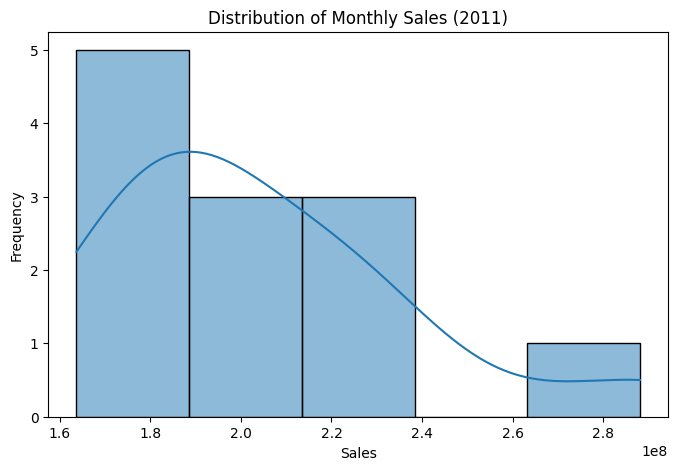

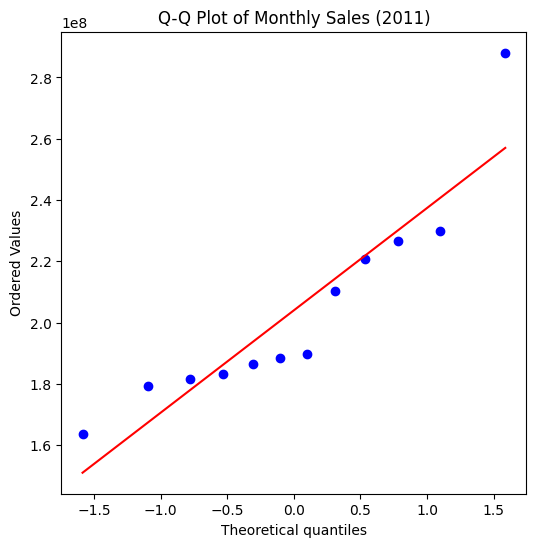

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# Filter data for year 2011
df_2011 = df[df['year'] == 2011]

# Aggregate sales by month
monthly_sales_2011 = df_2011.groupby('month')['sales'].sum().reset_index()

print("===== MONTHLY SALES (2011) =====")
print(monthly_sales_2011)

# ---------------------------
# Normality Test (Shapiro-Wilk)
# ---------------------------
stat, p_value = shapiro(monthly_sales_2011['sales'])

print("\n===== SHAPIRO-WILK TEST =====")
print(f"Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Sales are NOT normally distributed (Reject H0)")
else:
    print("Conclusion: Sales are normally distributed (Fail to Reject H0)")

# ---------------------------
# Visualization: Distribution
# ---------------------------
plt.figure(figsize=(8,5))
sns.histplot(monthly_sales_2011['sales'], kde=True)
plt.title("Distribution of Monthly Sales (2011)")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Q-Q plot (optional but strong for interviews)
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(monthly_sales_2011['sales'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Monthly Sales (2011)")
plt.show()